In [1]:
def readGenome(filename):
    genome = ""
    with open(filename,'r') as f:
        for line in f:
            if not line[0] == ">":
                genome += line.rstrip()
    return genome


In [2]:
genome = readGenome(r"F:\Coursera\Algorithms for DNA sequences\phix.fa") #Add your file path as an argument


In [3]:
def naive(p,t):
    """Matches the occurences of pattern 'p' in text 't'."""
    occurences = []
    for i in range(len(t)-len(p)+1):
        match = True
        for j in range(len(p)):
            if not t[i+j] == p[j]:
                match = False
                break
        if match:
            occurences.append(i)
    return occurences


In [4]:
def naive_2mm(p,t, distance):
    """Matches the occurences of pattern 'p' in text 't' with defined mismatches."""
    occurences = []
    for i in range(len(t)-len(p)+1):
        match = True
        mismatch = 0
        for j in range(len(p)):
            if t[i+j] == p[j]:
                match
            if not t[i+j] == p[j]:
                mismatch += 1
            if mismatch > distance: #Defined mismatches to '2'. It is customizable.
                match = False
                break
        if match:
            occurences.append(i)
    return occurences
total = naive_2mm("AGGAGGTT", genome, 2) #Example of counting the number of occurences of a pattern in a genome
print(len(total))


42


In [5]:
import random
def generateReads(genome, numreads, readlen):
    """Generate reads from a random positions within genome"""
    reads = []
    for _ in range(numreads):
        start = random.randint(0, len(genome)-readlen) - 1
        reads.append(genome[start:start+ readlen])
    return reads


In [6]:
reads = generateReads(genome, 100, 100)
"""Checking the naive function with randomly created reads"""

numMatched = 0
for r in reads:
    matches = naive(r, genome)      #returns list('matches') that containes the occureneces of reads in genome
    if len(matches)> 0:
        numMatched += 1             #counts the number of matches of a particular read at place against the genome.
print("%d / %d reads matched!" % (numMatched, len(reads)))


100 / 100 reads matched!


In [7]:
def Readfastq(filename):
    sequences = []
    qualities = []
    with open(filename) as f:
        while True:
            f.readline()                #ignore first line of a read i.e., Name
            seq = f.readline().rstrip() # removes white space while reading only added sequence
            f.readline()                #ignore third line of a read i.e., placeholder strand (+ or -)
            qual = f.readline().rstrip() # removes white space while reading only added ASCII encoded Quality Value
            if len(seq) == 0:
                break
            sequences.append(seq)
            qualities.append(qual)
    return sequences, qualities


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [9]:
seq_reads, _ = Readfastq(r"F:\Coursera\Algorithms for DNA sequences\ERR266411_1.first1000.fastq")  #Add your file path as an argument
"""Performing the naivev function with actual seq_reads"""

tried_reads = []            # to keep track of which reads were tried for matching against the genome (for visualization purposes)
matching_results = []       # to keep track of the matching results of whole reads against the genome (True if matched, False if not matched)- for visualization purposes
Total_match = []            # to keep track of the total number of matches of reads against the genome (for visualization purposes)

numMatched = 0
n = 0       # to keep track of how many reads were processed

for r in seq_reads:
    
    matches = naive(r, genome)
    n += 1
    
    tried_reads.append(n)
    Ditto = True if len(matches) > 0 else False     #Ditto is a boolean variable that indicates whether the read matched against the genome or not. It is True if there is at least one match, and False if there are no matches.
    matching_results.append(Ditto)

    if len(matches) > 0:
        numMatched += 1
    
    Total_match.append(numMatched)

print("%d / %d reads matched against the genome!" % (numMatched, n))

# The code above results in a very few matches of reads against the genome even though the Fastq reads and genome are of the same species.
# This might be due to error of sequencing machine.


7 / 1000 reads matched against the genome!


In [10]:
# Creating a dataframe to visualize the matching results of reads against the genome
Matching_table = pd.DataFrame({"Reads tried": tried_reads, "Total Match": Total_match, "Matching Results": matching_results}, index=range(1, len(tried_reads)+1))
Total_Match_Table = Matching_table.iloc[:, [0, 1]]

Total_Match_Table.head()


,Reads tried,Total Match
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0


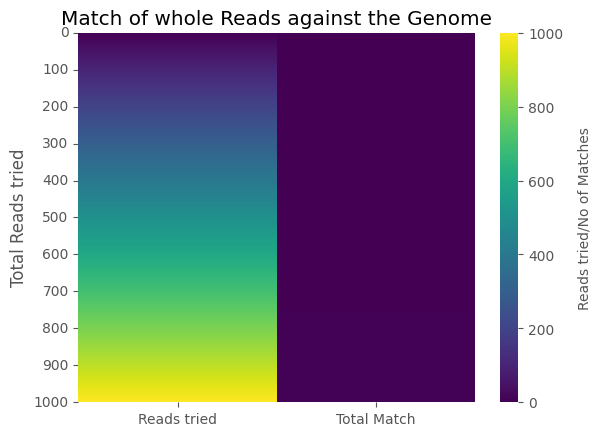

7 / 1000 reads matched against the genome!


In [102]:
from matplotlib import ticker

ax = sns.heatmap(Total_Match_Table, annot=False, cmap="viridis") #annot=False to remove the numbers in the heatmap
cbar = ax.collections[0].colorbar  
cbar.set_label("Reads tried/No of Matches", fontsize=10, labelpad=10)
plt.title("Match of whole Reads against the Genome")
plt.ylabel("Total Reads tried")
ax.set_yticks(range(0, len(Total_Match_Table)+1, 100))
ax.set_yticklabels(range(0, len(Total_Match_Table)+1, 100))
plt.show()
print("%d / %d reads matched against the genome!" % (numMatched, n))


In [100]:
Bool_table = pd.DataFrame({"Reads tried": tried_reads, "Matching Results": matching_results}, index=range(1, len(tried_reads)+1))
Bool_table["Matching Results"].value_counts()


Matching Results
False    993
True       7
Name: count, dtype: int64

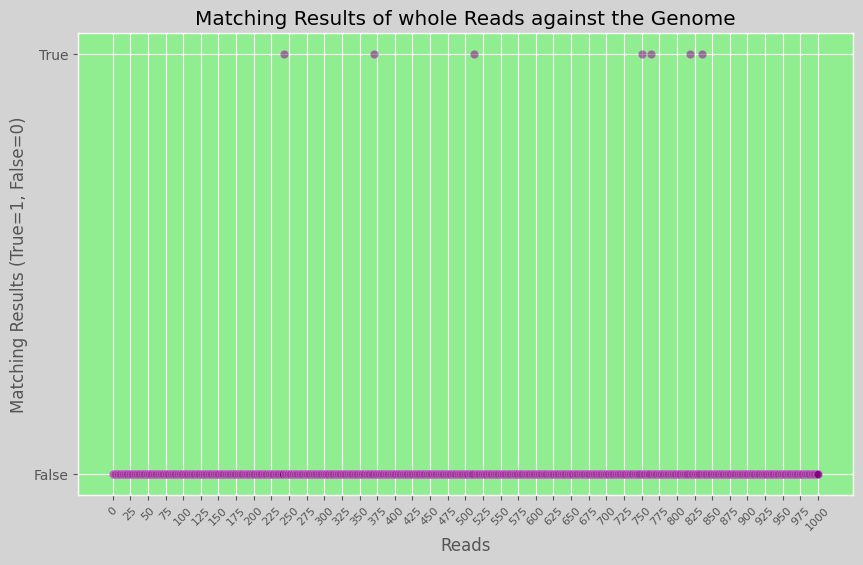

In [153]:
plt.style.use('ggplot')  # Use ggplot style for better aesthetics
# Create figure with custom background color
fig = plt.figure(facecolor='lightgray', figsize=(10,6))  # Outer background

# Add subplot with custom background color
ax = fig.add_subplot(111, facecolor='lightgreen')  # Inner plot background

ax.scatter(Bool_table["Reads tried"], Bool_table["Matching Results"], c = 'purple', alpha=0.5, edgecolor='plum')
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['False', 'True'])
ax.set_xticks(range(0, len(Bool_table)+1, 25))
ax.set_xticklabels(range(0, len(Bool_table)+1, 25), rotation=45, size=8)
plt.xlabel("Reads")
plt.ylabel("Matching Results (True=1, False=0)")
plt.title("Matching Results of whole Reads against the Genome")
plt.show()


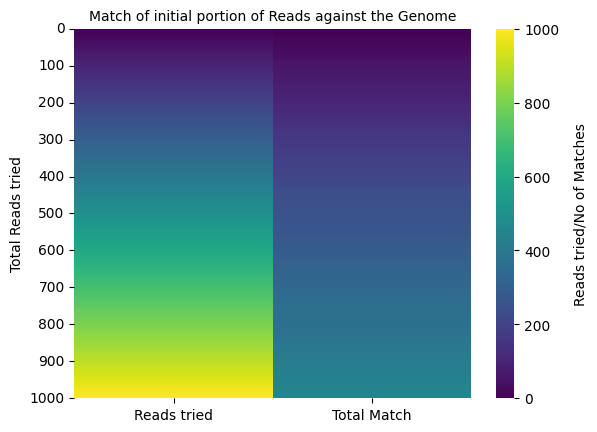

459 / 1000 reads matched against the genome!


In [25]:
#The code below tries to match only the portion of read against the genome to obtain the expected higher.
"""Performing the naivev function with actual seq_reads"""

tried_reads_portion = []            # to keep track of which reads were tried for matching against the genome (for visualization purposes)
matching_results_portion = []       # to keep track of the matching results of initial portion of reads against the genome (True if matched, False if not matched)- for visualization purposes
Total_match_portion = []              # to keep track of the total number of matches of reads against the genome (for visualization purposes)
numMatched_por = 0
n_por = 0       # to keep track of how many reads were processed
for r in seq_reads:
    r = r[:30]
    matches = naive(r, genome)
    n_por += 1

    tried_reads_portion.append(n_por)
    Ditto = True if len(matches) > 0 else False   #Ditto is a boolean variable that indicates whether the read matched against the genome or not. It is True if there is at least one match, and False if there are no matches.
    matching_results_portion.append(Ditto)

    if len(matches) > 0:
        numMatched_por += 1
    Total_match_portion.append(numMatched_por)

# Creating a dataframe to visualize the matching results of reads against the genome
Matching_table_portion = pd.DataFrame({"Reads tried": tried_reads_portion, "Total Match": Total_match_portion, "Matching Results": matching_results_portion})
Total_Match_Table_portion = Matching_table_portion.iloc[:, [0, 1]]


ax = sns.heatmap(Total_Match_Table_portion, annot=False, cmap="viridis") #annot=False to remove the numbers in the heatmap
cbar = ax.collections[0].colorbar  
cbar.set_label("Reads tried/No of Matches", fontsize=10, labelpad=10)
plt.title("Match of initial portion of Reads against the Genome", fontsize=10)
plt.ylabel("Total Reads tried")
ax.set_yticks(range(0, len(Total_Match_Table_portion)+1, 100))
ax.set_yticklabels(range(0, len(Total_Match_Table_portion)+1, 100))
plt.show()
print("%d / %d reads matched against the genome!" % (numMatched_por, n_por))

# The output matches are significantly increased though it is only less than half of the genome.
# This is because the genome is double stranded while particular reads come from either strand of the genome.


In [ ]:
Bool_table_por = pd.DataFrame({"Reads tried": tried_reads_portion, "Matching Results": matching_results_portion}, index=range(1, len(tried_reads_portion)+1))
Bool_table_por["Matching Results"].value_counts()


Matching Results
False    541
True     459
Name: count, dtype: int64

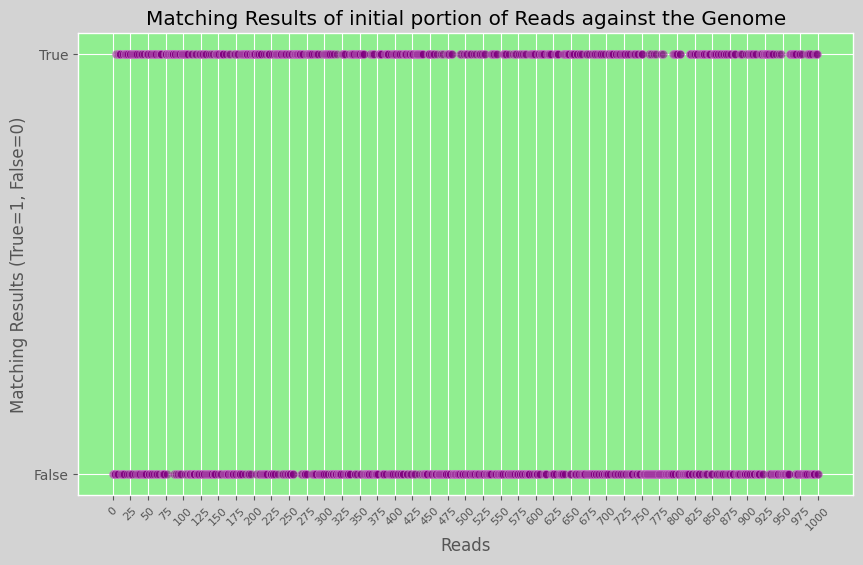

In [151]:
plt.style.use('ggplot')  # Use ggplot style for better aesthetics
# Create figure with custom background color
fig = plt.figure(facecolor='lightgray', figsize=(10,6))  # Outer background

# Add subplot with custom background color
ax = fig.add_subplot(111, facecolor='lightgreen')  # Inner plot background

ax.scatter(Bool_table_por["Reads tried"], Bool_table_por["Matching Results"], c = 'purple', alpha=0.5, edgecolor='plum')
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['False', 'True'])
ax.set_xticks(range(0, len(Bool_table_por)+1, 25))
ax.set_xticklabels(range(0, len(Bool_table_por)+1, 25), rotation=45, size=8)
plt.xlabel("Reads")
plt.ylabel("Matching Results (True=1, False=0)")
plt.title("Matching Results of initial portion of Reads against the Genome")
plt.show()


In [17]:
def reverseComplement(S):
    complement = {"A":"T","T":"A","C":"G","G":"C", "N":"N"} # Here, 'N' is the nucleotide in a read for which sequencer is not confident enough to make a call between any four nucleotide
    t = ""
    for base in S:
        t = complement[base] + t
    return t


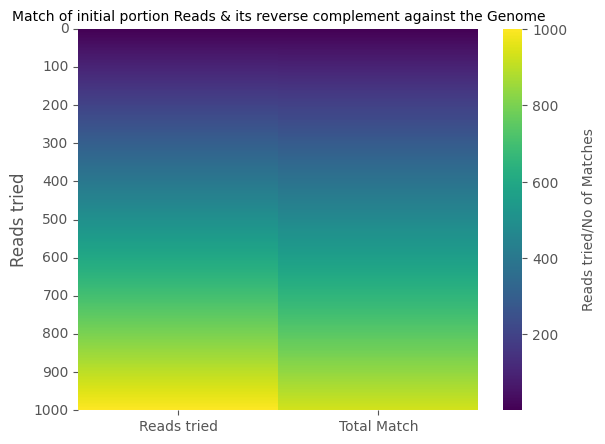

932 / 1000 reads matched against the genome!


In [55]:
# This code below compares the reads as well as reversecomplement of reads against the genome.
"""Performing the naivev function with actual seq_reads"""

tried_reads_rev_por = []                    # to keep track of which reads were tried for matching against the genome (for visualization purposes)
matching_results_rev_por = []               # to keep track of the matching results of initial portion of reads and its reverse complement against the genome (True if matched, False if not matched)- for visualization purposes
Total_match_rev_por = []                    # to keep track of the total number of matches of reads against the genome (for visualization purposes)

numMatched_rev_por = 0
n_rev_por = 0       # to keep track of how many reads were processed
for r in seq_reads:
    r = r[:30]
    reverse_r = reverseComplement(r)    
    matches = naive(r, genome) # Returns the list of matches of forward read against the genome
    if not reverse_r == r:
        matches_r = naive(reverse_r, genome)
        matches.extend(matches_r) # extend the above list by adding the lists containing the matches of reverse complement of that read against the genome
    n_rev_por += 1

    tried_reads_rev_por.append(n_rev_por)
    Ditto = True if len(matches) > 0 else False  # Ditto is a boolean variable that indicates whether the read matched against the genome or not. It is True if there is at least one match, and False if there are no matches.
    matching_results_rev_por.append(Ditto)

    if len(matches) > 0:
        numMatched_rev_por += 1

    Total_match_rev_por.append(numMatched_rev_por)  



# Creating a dataframe to visualize the matching results of reads against the genome
Matching_table_rev_por = pd.DataFrame({"Reads tried": tried_reads_rev_por, "Total Match": Total_match_rev_por, "Matching Results": matching_results_rev_por})
Total_Match_Table_rev_por = Matching_table_rev_por.iloc[:, [0, 1]]


ax = sns.heatmap(Total_Match_Table_rev_por, annot=False, cmap="viridis") #annot=False to remove the numbers in the heatmap
cbar = ax.collections[0].colorbar  
cbar.set_label("Reads tried/No of Matches", fontsize=10, labelpad=10)
plt.title("Match of initial portion Reads & its reverse complement against the Genome", fontsize=10)

plt.subplots_adjust(top=0.85)
plt.ylabel("Reads tried")
ax.set_yticks(range(0, len(Total_Match_Table_rev_por)+1, 100))
ax.set_yticklabels(range(0, len(Total_Match_Table_rev_por)+1, 100))
plt.tight_layout(pad=2.0)
plt.show()
print("%d / %d reads matched against the genome!" % (numMatched_rev_por, n_rev_por))


In [75]:
Bool_table_rev_por = pd.DataFrame({"Reads tried": tried_reads_rev_por, "Matching Results": matching_results_rev_por}, index=range(1, len(tried_reads_rev_por)+1))
Bool_table_rev_por["Matching Results"].value_counts()


Matching Results
True     932
False     68
Name: count, dtype: int64

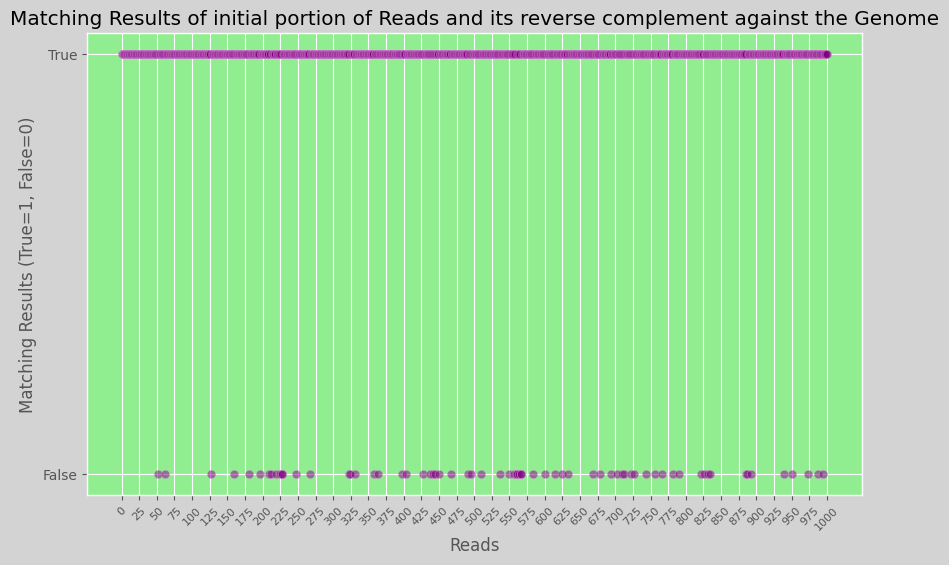

In [154]:
plt.style.use('ggplot')  # Use ggplot style for better aesthetics# Create figure with custom background color
fig = plt.figure(facecolor='lightgray', figsize=(10,6))  # Outer background

# Add subplot with custom background color
ax = fig.add_subplot(111, facecolor='lightgreen')  # Inner plot background

ax.scatter(Bool_table_rev_por["Reads tried"], Bool_table_rev_por["Matching Results"], c = 'purple', alpha=0.5, edgecolor='plum')
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['False', 'True'])
ax.set_xticks(range(0, len(Bool_table_rev_por)+1, 25))
ax.set_xticklabels(range(0, len(Bool_table_rev_por)+1, 25), rotation=45, size=8)
plt.xlabel("Reads")
plt.ylabel("Matching Results (True=1, False=0)")
plt.title("Matching Results of initial portion of Reads and its reverse complement against the Genome")
plt.show()

